(100, 33)


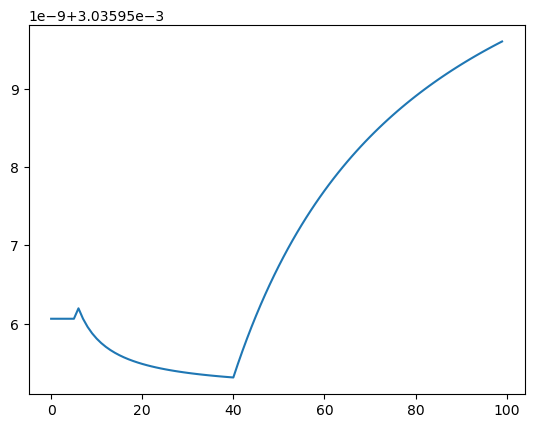

[9.0]
[np.float64(0.003035957084980897)]


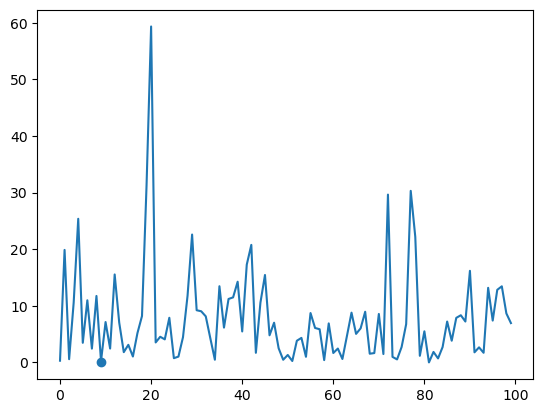

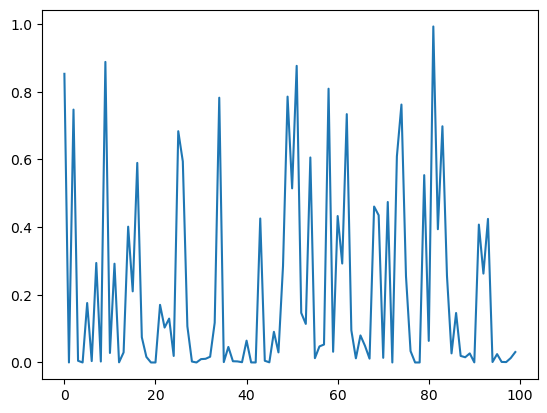

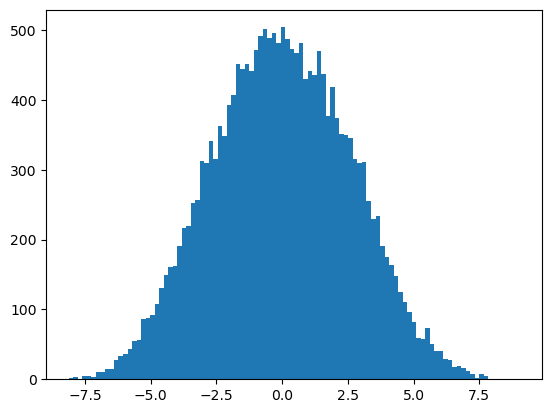

In [46]:
# load sample_np.npy
import numpy as np
import matplotlib.pyplot as plt

j = 1
dir = '/pscratch/sd/r/reubenh/storage'
num_unadjusted_steps = 1
numsteps = 100
j_r = 1
num_chains = 20000
# dir = '../../../'
g_vals = []
# times = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
times = [9.0]
burn_in = 0
for time in times:
# for time in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    # samples_np = np.load(f'../../../samples_np_{time}_{j}.npy')
    samples_np = np.load(f'{dir}/samples_np_flat_quartic_{time}_{burn_in}_{num_unadjusted_steps}_{numsteps}_{num_chains}_{j_r}.npy')
    jb_stats = np.load(f'{dir}/jb_stats_flat_quartic_{time}_{burn_in}_{num_unadjusted_steps}_{numsteps}_{num_chains}_{j_r}.npy')
    jb_pvalues = np.load(f'{dir}/jb_pvalues_flat_quartic_{time}_{burn_in}_{num_unadjusted_steps}_{numsteps}_{num_chains}_{j_r}.npy')

    raw_samples = np.load(f'{dir}/raw_samples_flat_quartic_{time}_{burn_in}_{num_unadjusted_steps}_{numsteps}_{num_chains}_{j_r}.npy')

    chi_samples = np.load(f'{dir}/chi_samples_flat_quartic_{time}_{burn_in}_{num_unadjusted_steps}_{numsteps}_{num_chains}_{j_r}.npy')
    # acc_probs = np.load(f'../../../acc_probs_{time}_{j}.npy')
    # std_errs = np.load(f'../../../std_errs_{time}_{j}.npy')

    obs = samples_np[burn_in:, 0]*samples_np[burn_in:, -1]
    # cumulative avg of obs
    obs = np.cumsum(obs) / np.arange(1, len(obs) + 1)
    print(samples_np.shape)
    g_vals.append(obs.mean())
    plt.plot(obs)
    plt.show()
    plt.clf()
    # plt.plot(std_errs)
    # plt.show()
    # plt.clf()
    # plt.plot(acc_probs)
    # plt.clf()

plt.scatter(times, g_vals)
    # obs.shape
    # plot the first 1000 samples
# plt.hist(obs, bins=50, density=True)
# plt.savefig('samples_np_2.0.png')
# ts

print(times)
print(g_vals)
plt.plot(jb_stats)
plt.show()

plt.plot(jb_pvalues)
plt.show()

# raw_samples.shape

plt.hist(raw_samples[1, :], bins=100)
mean = raw_samples[1, :].mean()
std = raw_samples[1, :].std()
gaussian = lambda x: (1/(std*np.sqrt(2*np.pi)))*np.exp(-(x-mean)**2/(2*std**2))
# x = np.linspace(mean-50*std, mean+50*std, 100)
# plt.plot(x, gaussian(x), color='r')
plt.show()


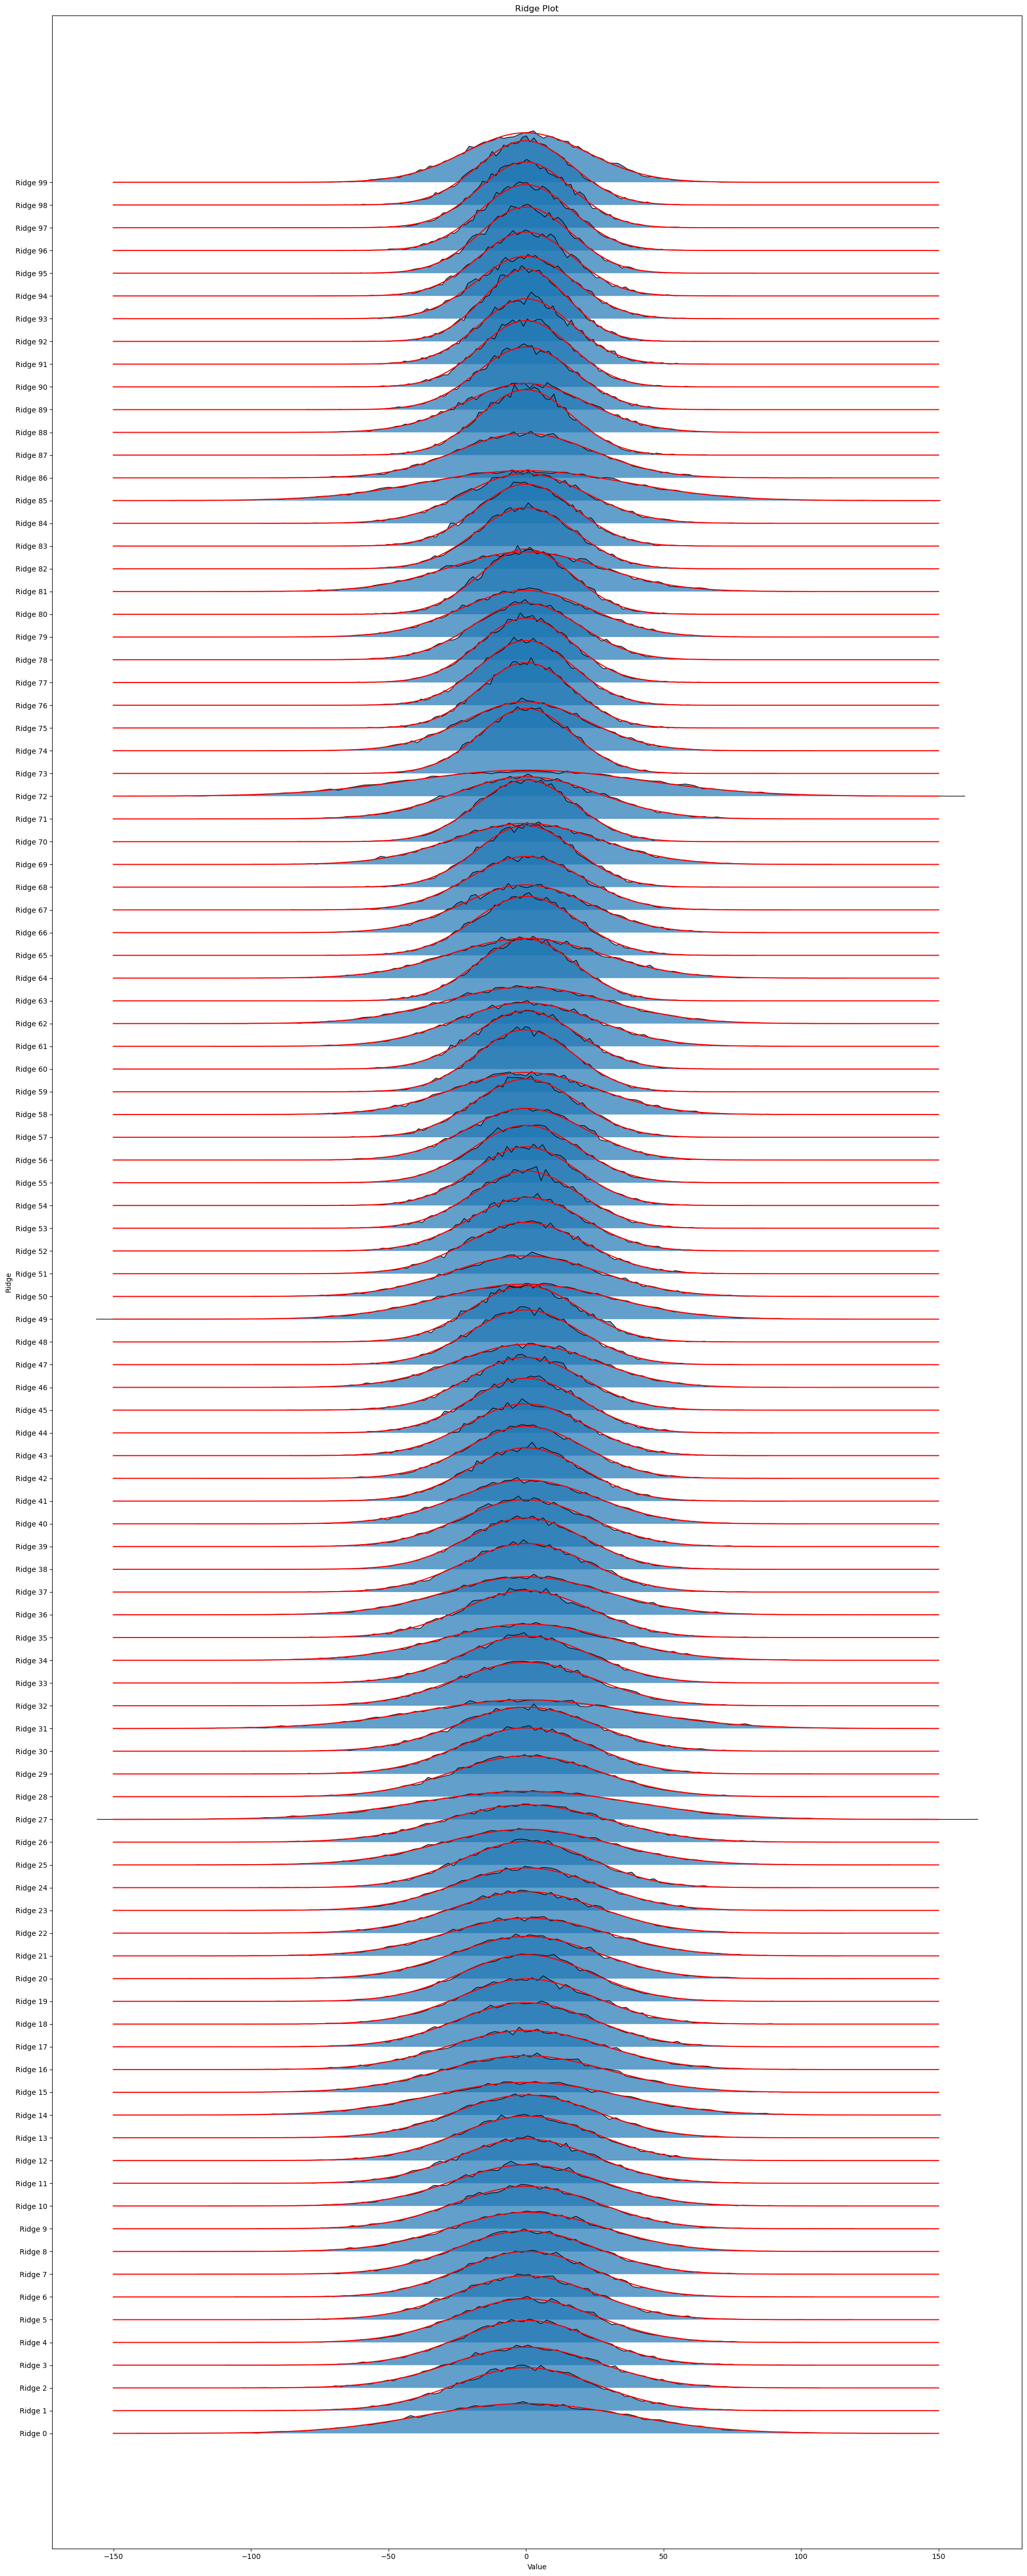

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def ridge_plot(data, bins=100, overlap=0.5, colors=None, labels=None, figsize=(20, 50)):
    """
    Create a ridge plot (stacked histograms) for a 2D array.
    Args:
        data: array-like, shape (num_ridges, num_samples)
        bins: number of bins for the histogram
        overlap: float, amount of overlap between ridges (0 to 1)
        colors: list of colors for each ridge (optional)
        labels: list of str, labels for each ridge (optional)
        figsize: tuple, size of the figure
    """
    num_ridges = data.shape[0]
    plt.figure(figsize=figsize)
    
    # Normalize vertical spacing by max histogram height
    max_hist_height = 0
    all_hist_vals = []
    all_edges = []
    means = []
    stds = []
    for i in range(num_ridges):
        hist_vals, bin_edges = np.histogram(data[i], bins=bins, density=True)
        all_hist_vals.append(hist_vals)
        all_edges.append(bin_edges)
        mean = data[i].mean()
        std = data[i].std()
        means.append(mean)
        stds.append(std)
        max_hist_height = max(max_hist_height, hist_vals.max())
    
    # Define vertical step in y
    y_step = max_hist_height * (1-overlap)
    
    for i in range(num_ridges):
        vals = all_hist_vals[i]
        edges = all_edges[i]
        x = 0.5 * (edges[:-1] + edges[1:])
        yoffset = i * y_step
        color = None
        if colors is not None and len(colors) > i:
            color = colors[i]
        label = None
        if labels is not None and len(labels) > i:
            label = labels[i]
        plt.fill_between(x, yoffset, vals+yoffset, color=color, alpha=0.7, label=label)
        
        plt.plot(x, vals + yoffset, color="k", lw=0.9)

        # plot gaussian with mean and std at 100 points between -10 and 10
        x_points = np.linspace(-150, 150, 100)
        gaussian = lambda x: (1/(stds[i]*np.sqrt(2*np.pi)))*np.exp(-(x-means[i])**2/(2*stds[i]**2))
        plt.plot(x_points, gaussian(x_points) + yoffset, color='r')

    
    plt.yticks(y_step * np.arange(num_ridges), labels if labels is not None else [f"Ridge {i}" for i in range(num_ridges)])
    plt.xlabel("Value")
    plt.ylabel("Ridge")
    plt.title("Ridge Plot")
    if labels is not None:
        plt.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
# Suppose chi_samples has shape (num_ridges, num_samples)
ridge_plot(chi_samples[::1, :], bins=100, overlap=0.7)
# chi_samples.shape

In [ ]:
# load sample_np.npy
import numpy as np
import matplotlib.pyplot as plt

j = 1
dir = '/pscratch/sd/r/reubenh/storage'
# dir = '../../../'
g_vals = []
# times = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
times = [1.0]
burn_in = 0
for time in times:
# for time in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    # samples_np = np.load(f'../../../samples_np_{time}_{j}.npy')
    samples_np = np.load(f'{dir}/samples_np_flat_{time}_{j}.npy')
    # acc_probs = np.load(f'../../../acc_probs_{time}_{j}.npy')
    # std_errs = np.load(f'../../../std_errs_{time}_{j}.npy')

    obs = samples_np[burn_in:, 0]*samples_np[burn_in:, -1]
    # cumulative avg of obs
    obs = np.cumsum(obs) / np.arange(1, len(obs) + 1)
    print(samples_np.shape)
    g_vals.append(obs.mean())
    plt.plot(obs)
    plt.show()
    plt.clf()
    # plt.plot(std_errs)
    # plt.show()
    # plt.clf()
    # plt.plot(acc_probs)
    # plt.clf()

plt.scatter(times, g_vals)
    # obs.shape
    # plot the first 1000 samples
# plt.hist(obs, bins=50, density=True)
# plt.savefig('samples_np_2.0.png')
# ts

print(times)
print(g_vals)


In [4]:
list(zip(times, g_vals))

[(1.0, np.float64(0.5471541893234336)),
 (1.5, np.float64(0.1033022752461477)),
 (2.0, np.float64(-0.3884058111101705)),
 (2.5, np.float64(-0.8068648442743593)),
 (3.0, np.float64(-0.8837086347287477)),
 (3.5, np.float64(-0.9286662695603083)),
 (4.0, np.float64(-0.6945011598379935)),
 (4.5, np.float64(-0.3102114721505776)),
 (5.0, np.float64(0.09121182131633855)),
 (5.5, np.float64(0.5540652792924603)),
 (6.0, np.float64(1.0802162849194419)),
 (6.5, np.float64(0.7896104585184779)),
 (7.0, np.float64(0.7276343656962856)),
 (7.5, np.float64(0.21648169279212304)),
 (8.0, np.float64(-0.3239450164099265)),
 (8.5, np.float64(-0.9418580440870523)),
 (9.0, np.float64(-0.9694450657812175)),
 (9.5, np.float64(-4.666134153379831)),
 (10.0, np.float64(-0.5433606422844326))]

(10000000, 9)


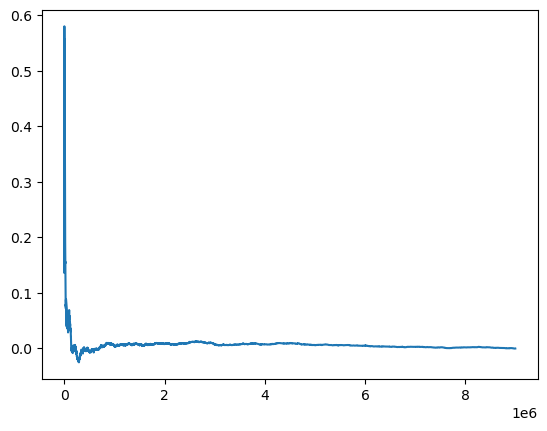

(10000000, 9)


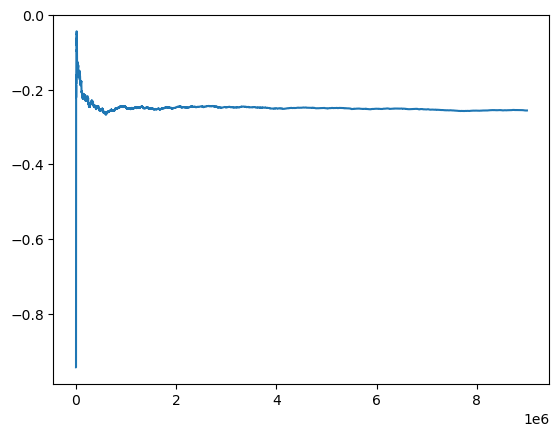

(10000000, 9)


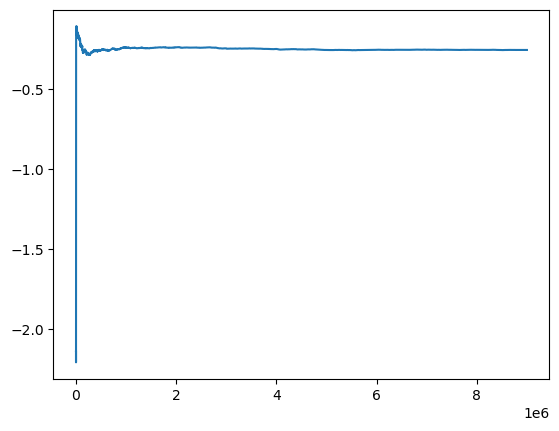

(10000000, 9)


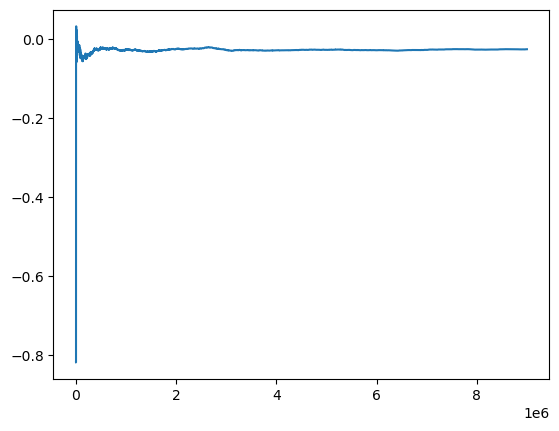

(10000000, 9)


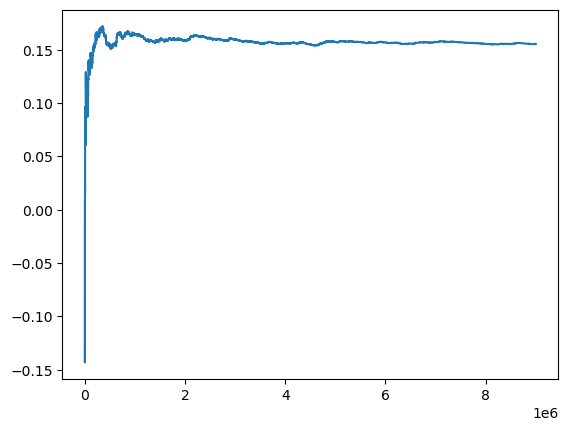

(10000000, 9)


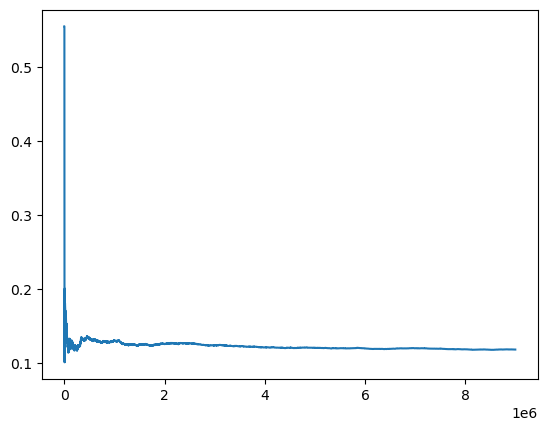

(10000000, 17)


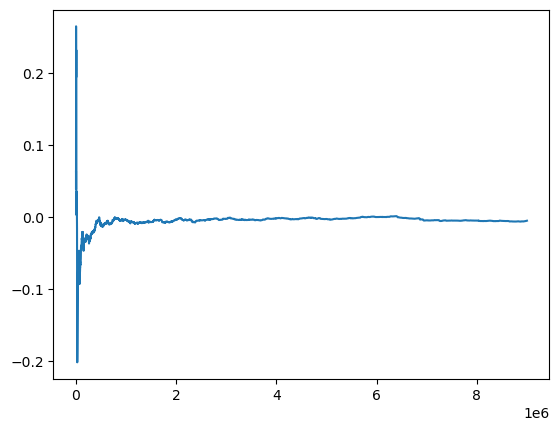

(10000000, 17)


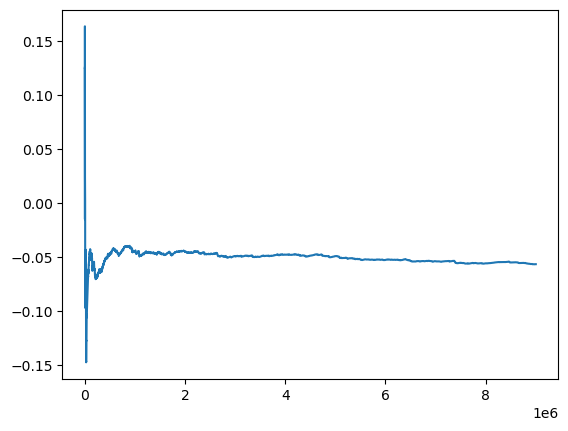

(10000000, 17)


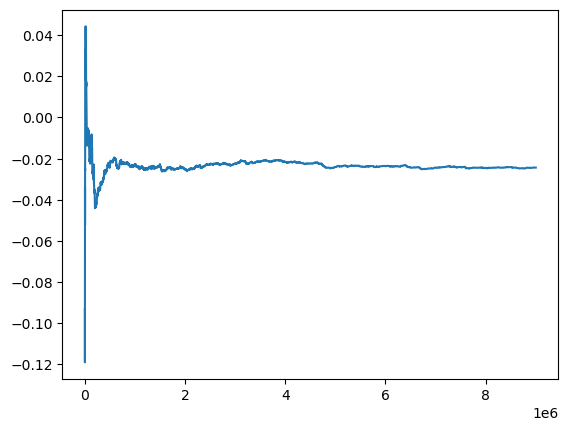

(10000000, 17)


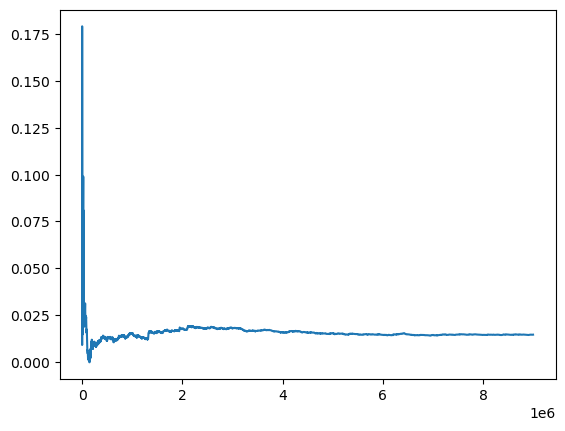

(10000000, 17)


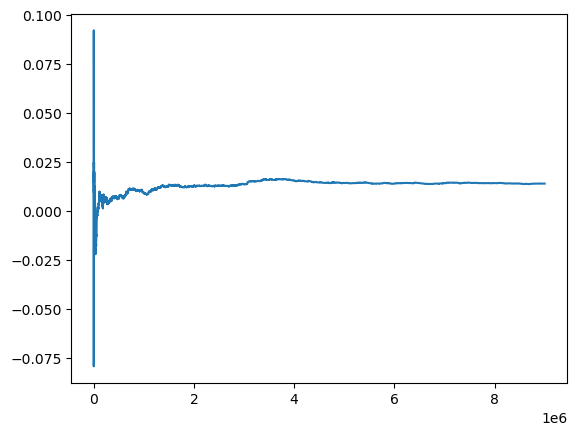

(10000000, 17)


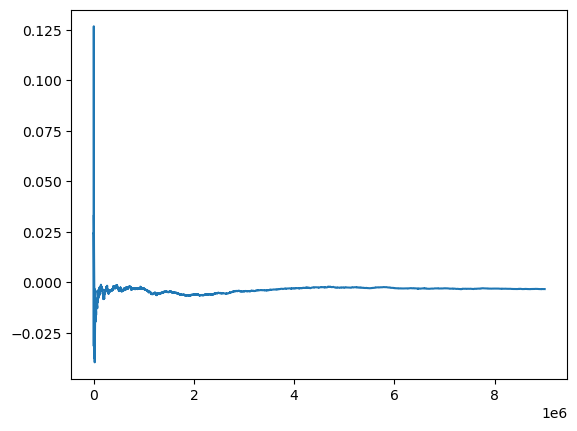

(10000000, 17)


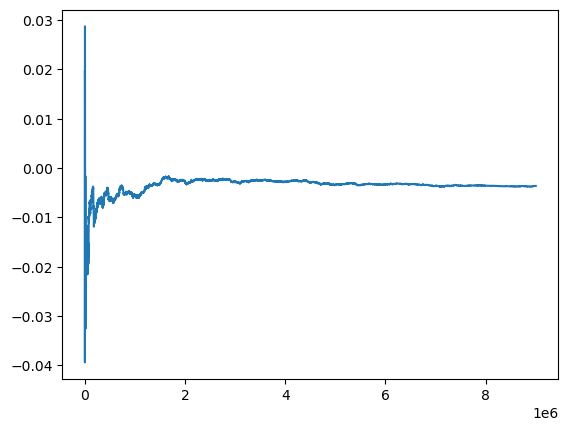

(10000000, 17)


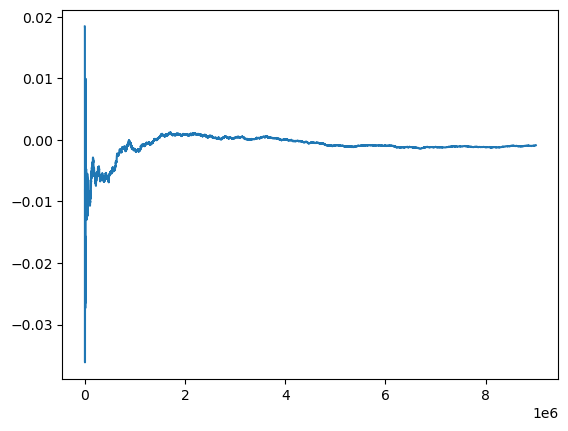

(10000000, 33)


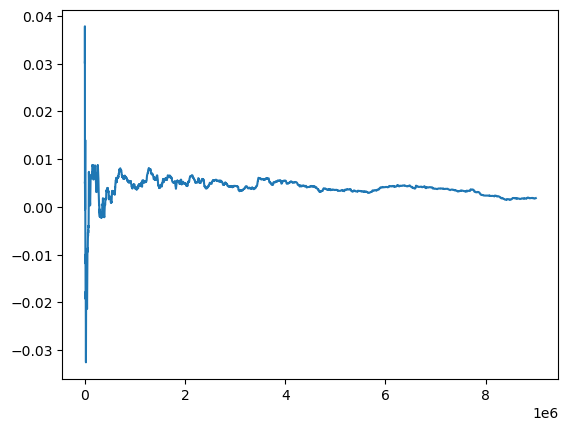

(10000000, 33)


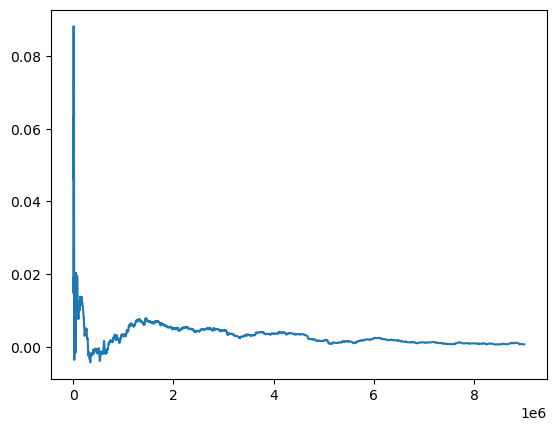

(10000000, 33)


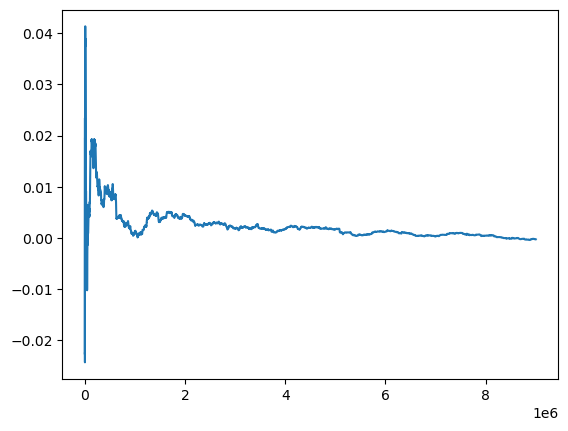

(10000000, 33)


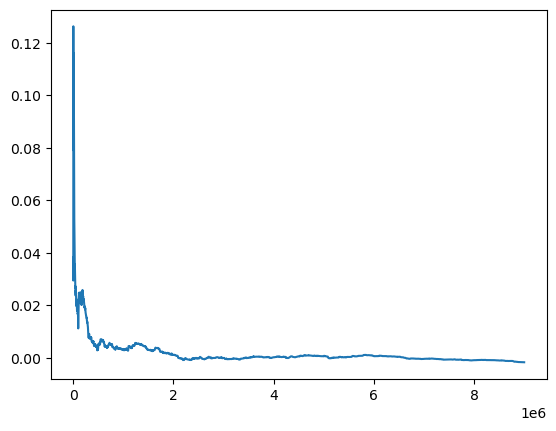

(10000000, 33)


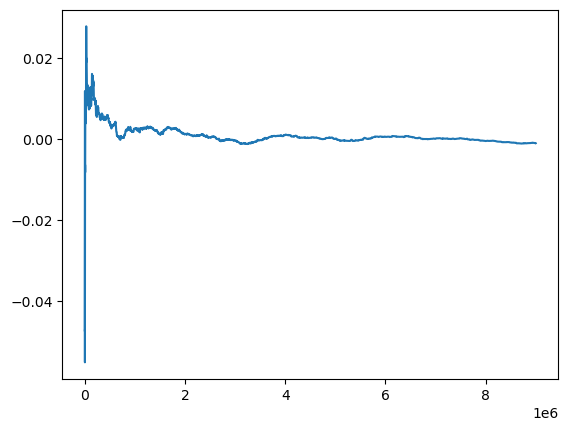

[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
[np.float64(0.005771025213977019), np.float64(-0.24903693369285254), np.float64(-0.2544653912399257), np.float64(-0.028420019775881974), np.float64(0.1569230362771354), np.float64(0.1218109223032572), np.float64(-0.004654819115821121), np.float64(-0.05079790939821505), np.float64(-0.02355397556719769), np.float64(0.01535789962008352), np.float64(0.013096977144214919), np.float64(-0.0036065963207251653), np.float64(-0.003566999520477129), np.float64(-0.0009176005667083371), np.float64(0.0039650351084188785), np.float64(0.0029977659117647625), np.float64(0.0021833542043091683), np.float64(0.0014329025699202982), np.float64(0.0007125376905037592)]


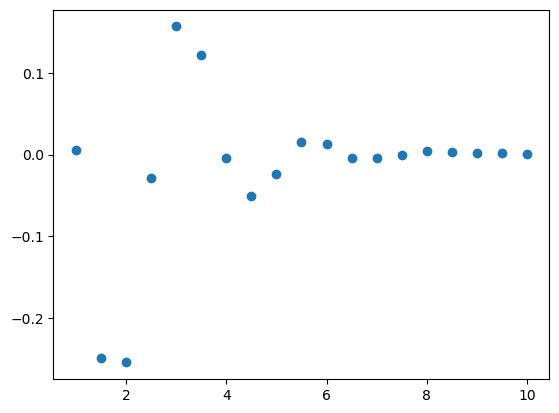

In [1]:
# load sample_np.npy
import numpy as np
import matplotlib.pyplot as plt

j = 1
dir = '/pscratch/sd/r/reubenh/storage'
# dir = '../../../'
g_vals = []
times = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
for time in times:
# for time in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    # samples_np = np.load(f'../../../samples_np_{time}_{j}.npy')
    samples_np = np.load(f'{dir}/samples_np_flat_quartic_{time}_{j}.npy')
    # acc_probs = np.load(f'../../../acc_probs_{time}_{j}.npy')
    # std_errs = np.load(f'../../../std_errs_{time}_{j}.npy')

    obs = samples_np[1000000:, 0]*samples_np[1000000:, -1]
    # cumulative avg of obs
    obs = np.cumsum(obs) / np.arange(1, len(obs) + 1)
    print(samples_np.shape)
    g_vals.append(obs.mean())
    plt.plot(obs)
    plt.show()
    plt.clf()
    # plt.plot(std_errs)
    # plt.show()
    # plt.clf()
    # plt.plot(acc_probs)
    # plt.clf()

plt.scatter(times, g_vals)
    # obs.shape
    # plot the first 1000 samples
# plt.hist(obs, bins=50, density=True)
# plt.savefig('samples_np_2.0.png')
# ts

print(times)
print(g_vals)


(1000000, 9)


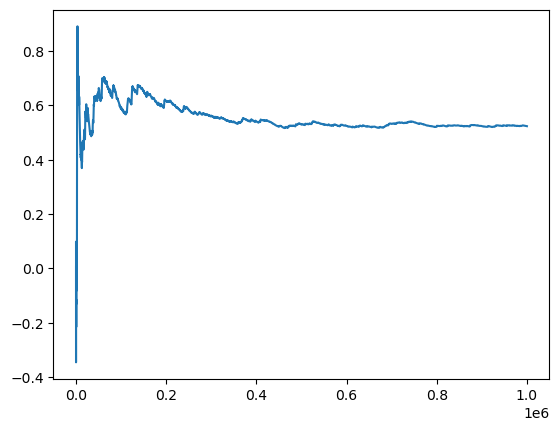

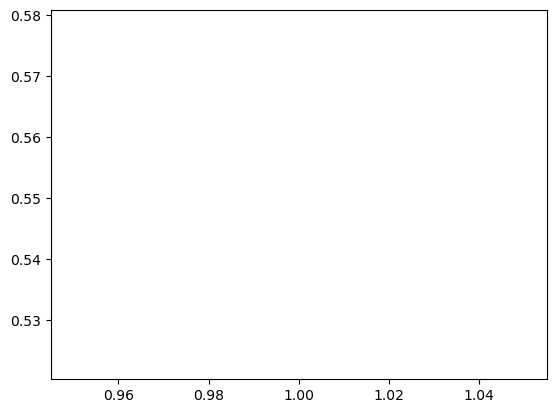

In [1]:
# load sample_np.npy
import numpy as np
import matplotlib.pyplot as plt

j = 1
g_vals = []
times = [1.0]
for time in times:
# for time in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    samples_np = np.load(f'../../../samples_np_{time}_{j}.npy')
    # acc_probs = np.load(f'../../../acc_probs_{time}_{j}.npy')
    # std_errs = np.load(f'../../../std_errs_{time}_{j}.npy')

    obs = samples_np[:, 0]*samples_np[:, -1]
    # cumulative avg of obs
    obs = np.cumsum(obs) / np.arange(1, len(obs) + 1)
    print(samples_np.shape)
    g_vals.append(obs.mean())
    plt.plot(obs)
    plt.show()
    plt.clf()
    # plt.plot(std_errs)
    # plt.show()
    # plt.clf()
    # plt.plot(acc_probs)
    # plt.clf()

plt.plot(times, g_vals)
    # obs.shape
    # plot the first 1000 samples
# plt.hist(obs, bins=50, density=True)
# plt.savefig('samples_np_2.0.png')
# ts


(500, 9)
(70000, 33)
(70000, 33)
(70000, 33)


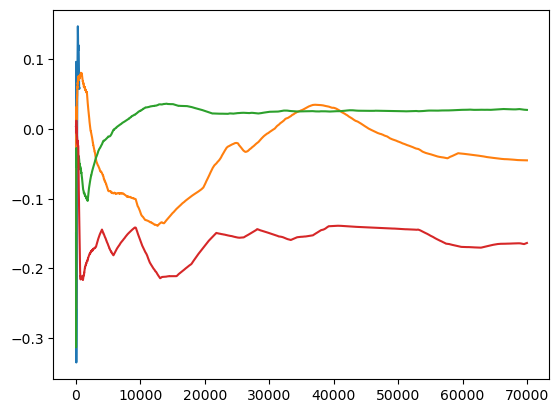

In [1]:
# load sample_np.npy
import numpy as np
import matplotlib.pyplot as plt

ts = []
times = [1.0, 2.0, 3.0, 4.0,]
for time in times:
# for time in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    samples_np = np.load(f'../../../samples_np_{time}.npy')

    obs = samples_np[:, 0]*samples_np[:, -1]
    # cumulative avg of obs
    obs = np.cumsum(obs) / np.arange(1, len(obs) + 1)
    print(samples_np.shape)
    # ts.append(obs.mean())
    plt.plot(obs)

# plt.plot(times, ts)
    # obs.shape
    # plot the first 1000 samples
# plt.hist(obs, bins=50, density=True)
# plt.savefig('samples_np_2.0.png')
# ts
